## Instalação de dependências e importação de bibliotecas

Este trecho de código realiza a configuração inicial do ambiente para uma análise de dados que envolve dados financeiros, web scraping e visualização.

- O comando `!pip install -r requirements.txt` instala todas as bibliotecas necessárias listadas no arquivo `requirements.txt` (como `yfinance`, `pandas`, `requests`, `beautifulsoup4`, `matplotlib` etc.), garantindo que o ambiente tenha as dependências corretas.
- Em seguida, são importadas as bibliotecas:
  - **yfinance**: para baixar dados históricos e informações de ações do Yahoo Finance.
  - **pandas**: para manipular e analisar dados estruturados em DataFrames.
  - **requests**: para fazer requisições HTTP (ex.: baixar páginas web ou APIs).
  - **BeautifulSoup (bs4)**: para extrair informações de documentos HTML/XML (web scraping).
  - **warnings**: para controlar mensagens de aviso durante a execução.
  - **json**: para ler e escrever dados no formato JSON.
  - **matplotlib.pyplot**: para criar gráficos e visualizações dos dados.
- Por fim, `warnings.filterwarnings('ignore')` suprime mensagens de aviso, mantendo a saída do notebook mais limpa e focada nos resultados principais.

**Objetivo:** Preparar o ambiente de análise de dados financeiros, possibilitando a coleta de dados via API (Yahoo Finance) e web scraping, a manipulação e limpeza dos dados com pandas, e a geração de gráficos, tudo sem poluição visual de avisos desnecessários.

In [1]:
!pip install -r requirements.txt

import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings
import json
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

## Descrição da função `make_graph(stock_data, revenue_data, stock)`

Esta função gera um gráfico composto por dois subgráficos empilhados verticalmente (2 linhas, 1 coluna) para visualizar a evolução histórica do preço das ações e da receita de uma determinada empresa.

### O que o código faz:
1. **Filtra os dados** – Cria dois DataFrames reduzidos:
   - `stock_data_specific`: contém os dados de preço da ação até a data `'2021-06-14'`.
   - `revenue_data_specific`: contém os dados de receita até a data `'2021-04-30'`.
2. **Configura a área de plotagem** – Utiliza `matplotlib.pyplot.subplots` para criar uma figura com dois eixos (axes) lado a lado verticalmente, com tamanho de 12x8 polegadas e compartilhando o eixo X.
3. **Plota o preço da ação** (primeiro subgráfico):
   - Converte a coluna `Date` para datetime e a coluna `Close` para float.
   - Linha azul com rótulo "Share Price".
   - Eixo Y: "Price ($US)".
   - Título: `"{stock} - Historical Share Price"`.
4. **Plota a receita** (segundo subgráfico):
   - Converte a coluna `Date` para datetime e a coluna `Revenue` para float.
   - Linha verde com rótulo "Revenue".
   - Eixo Y: "Revenue ($US Millions)".
   - Eixo X: "Date".
   - Título: `"{stock} - Historical Revenue"`.
5. **Ajusta o layout** com `tight_layout()` para evitar sobreposição de elementos e exibe o gráfico com `plt.show()`.

### Objetivo da função:
Permitir a comparação visual entre a trajetória do preço das ações e o desempenho da receita ao longo do tempo, ajudando a identificar possíveis correlações ou defasagens entre os dois indicadores financeiros. A função é útil em análises exploratórias de dados financeiros, especialmente para empresas de capital aberto.

In [2]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Código para obter dados históricos da Tesla (TSLA)

Este trecho utiliza a biblioteca `yfinance` para extrair informações históricas de preços e volumes das ações da Tesla.

### O que o código faz:
1. `tesla = yf.Ticker('TSLA')` – Cria um objeto `Ticker` associado ao símbolo `TSLA` (Tesla Inc.).
2. `tesla_data = tesla.history(period="max")` – Busca todo o histórico disponível de dados da ação (desde o início dos registros até o presente), incluindo colunas como Open, High, Low, Close, Volume, Dividendos, Splits, etc.
3. `tesla_data` – Exibe o DataFrame resultante (em um ambiente interativo como Jupyter Notebook), mostrando as primeiras e últimas linhas automaticamente.

### Objetivo:
Coletar e armazenar os dados históricos completos da Tesla para análises posteriores, como cálculo de retornos, médias móveis, visualização da evolução do preço ou comparação com receitas (conforme a função `make_graph` anterior). O parâmetro `period="max"` garante a maior janela temporal disponível.

In [3]:
tesla = yf.Ticker('TSLA')
tesla_data = tesla.history(period="max")
tesla_data

C:\Users\Renan Silva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-01 00:00:00-04:00,378.630005,383.140015,374.079987,381.260010,58683800,0.0,0.0
2026-04-02 00:00:00-04:00,364.200012,370.279999,359.029999,360.589996,83031200,0.0,0.0
2026-04-06 00:00:00-04:00,362.589996,367.720001,346.640015,352.820007,77697600,0.0,0.0


## Transformação do índice e visualização inicial dos dados da Tesla

Este trecho ajusta a estrutura do DataFrame `tesla_data` e exibe suas primeiras linhas.

### O que o código faz:
1. `tesla_data.reset_index(inplace=True)` – Converte o índice atual do DataFrame (que geralmente contém as datas) em uma coluna chamada `'Date'`. O parâmetro `inplace=True` modifica o próprio DataFrame sem precisar reatribuí-lo. Isso é útil porque o `yfinance` costuma retornar o índice como DatetimeIndex.
2. `tesla_data.head()` – Exibe as primeiras 5 linhas do DataFrame após a transformação, mostrando agora a coluna `Date` ao lado das colunas de preços (Open, High, Low, Close, Volume, etc.).

### Objetivo:
- Facilitar operações que exigem a data como coluna comum (ex.: filtrar por intervalo de datas, mesclar com outras tabelas, ou usar diretamente em funções de plotagem que esperam uma coluna `Date`).
- Verificar rapidamente se a transformação funcionou e como os dados estão estruturados.

In [4]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Extração de dados de receita da Tesla a partir de uma página HTML

Este trecho realiza web scraping para obter dados tabulares de receita histórica da Tesla, utilizando as bibliotecas `requests` e `BeautifulSoup`.

### O que o código faz:
1. Define a `url` apontando para um arquivo HTML hospedado no IBM Cloud, contendo dados financeiros da Tesla (provavelmente tabelas de receita).
2. `requests.get(url).text` – Faz uma requisição HTTP GET à URL e extrai o conteúdo HTML como texto.
3. `BeautifulSoup(html_data, 'html.parser')` – Cria um objeto `soup` que permite navegar e buscar elementos no HTML estruturado.
4. `soup.find_all("table")[1]` – Localiza todas as tags `<table>` presentes no documento e seleciona a segunda tabela (índice 1, pois o índice 0 é a primeira tabela). Essa tabela específica contém os dados históricos de receita trimestral da Tesla.

### Objetivo:
Coletar os dados de receita da Tesla diretamente de uma fonte HTML estruturada, sem depender de APIs externas. O resultado (`tables`) é um objeto `BeautifulSoup` representando a tabela, que posteriormente será convertido em um DataFrame (por exemplo, com `pd.read_html` ou extraindo linhas e colunas manualmente) para análise e visualização em conjunto com os dados de preço das ações.

In [5]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, 'html.parser')
tables = soup.find_all("table")[1]

## Construção do DataFrame de receita da Tesla a partir de tabela HTML

Este trecho processa a tabela HTML extraída anteriormente (variável `tables`) para criar um DataFrame estruturado com duas colunas: `Date` e `Revenue`.

### O que o código faz:
1. `tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])` – Inicializa um DataFrame vazio com as colunas "Date" e "Revenue".
2. `for row in tables.tbody.find_all("tr"):` – Itera sobre cada linha (tag `<tr>`) dentro do corpo da tabela (`<tbody>`).
3. `col = row.find_all("td")` – Localiza todas as células da linha (tags `<td>`).
4. `if col:` – Verifica se a linha contém células (ignorando linhas vazias ou de cabeçalho com `<th>`).
5. `date = col[0].text.strip()` – Extrai o texto da primeira célula (data), removendo espaços extras.
6. `revenue = col[1].text.strip()` – Extrai o texto da segunda célula (receita), também com `.strip()`.
7. `new_row = pd.DataFrame([{"Date": date, "Revenue": revenue}])` – Cria um DataFrame temporário com uma única linha.
8. `tesla_revenue = pd.concat([tesla_revenue, new_row], ignore_index=True)` – Concatena essa nova linha ao DataFrame principal, reindexando os índices automaticamente.
9. `tesla_revenue.head()` – Exibe as primeiras 5 linhas do DataFrame final.

### Objetivo:
Converter dados semi-estruturados de uma tabela HTML em um DataFrame limpo e utilizável no pandas. Essa estrutura tabular permite análises futuras (ex.: conversão de valores para numérico, filtragem por data, fusão com dados de preço das ações) e alimenta diretamente a função `make_graph` para visualização comparativa entre preço da ação e receita da Tesla.

In [9]:
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in tables.tbody.find_all("tr"):
    col = row.find_all("td")
    if col:
        date = col[0].text.strip()
        revenue = col[1].text.strip()

        new_row = pd.DataFrame([{"Date": date, "Revenue": revenue}])
        tesla_revenue = pd.concat([tesla_revenue, new_row], ignore_index=True)
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


## Limpeza e padronização da coluna de receita da Tesla

Este trecho realiza a higienização dos dados da coluna `Revenue` no DataFrame `tesla_revenue`, preparando-os para análises numéricas.

### O que o código faz:
1. `tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',|\$', "", regex=True)` – Remove todos os caracteres de vírgula (`,`) e cifrão (`$`) da coluna `Revenue` usando expressão regular. Exemplo: `"$123,456"` vira `"123456"`.
2. `tesla_revenue.dropna(inplace=True)` – Remove linhas onde o valor da receita é `NaN` (valores ausentes), modificando o DataFrame diretamente.
3. `tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]` – Filtra e mantém apenas as linhas onde a receita não é uma string vazia (`""`), descartando entradas inválidas.
4. `tesla_revenue.tail()` – Exibe as últimas 5 linhas do DataFrame após a limpeza, permitindo verificar o final da série histórica.

### Objetivo:
Converter a coluna `Revenue` de um formato textual (com símbolos e separadores) para um formato numérico limpo, removendo inconsistências. Isso é essencial para:
- Plotar os valores no gráfico de receita (que espera `astype("float")` na função `make_graph`).
- Realizar cálculos como crescimento percentual, médias, etc.
- Garantir que dados faltantes ou vazios não causem erros ou distorções nas análises.

In [10]:
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace('[\\$,]',"",regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## Coleta e preparação dos dados históricos da GameStop (GME)

Obtém todo o histórico de preços da ação GME via `yfinance`, transforma o índice de datas em coluna `Date` e exibe as primeiras 5 linhas. Procedimento idêntico ao realizado para a Tesla, apenas alterando o ticker para `"GME"`.

In [11]:
game_stop = yf.Ticker("GME")
gme_data = game_stop.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()

C:\Users\Renan Silva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Extração da tabela de receita da GameStop

Faz o scraping do HTML contido no link fornecido (arquivo `stock.html`), cria um objeto BeautifulSoup e seleciona a segunda tabela (`[1]`), que contém os dados históricos de receita da GameStop.

In [12]:
html_data_2 = requests.get("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html").text
soup_2 = BeautifulSoup(html_data_2, 'html.parser')
table1 = soup_2.find_all("table")[1]

## Construção do DataFrame de receita da GameStop

A partir da tabela HTML extraída (`table1`), itera sobre as linhas do `<tbody>`, extrai data e receita, e concatena em um DataFrame `gme_revenue` com colunas `Date` e `Revenue`. Estrutura idêntica à utilizada para a Tesla.

In [13]:
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in table1.tbody.find_all("tr"):
    col1 = row.find_all("td")
    if col1:
        date1 = col1[0].text.strip()
        revenue1 = col1[1].text.strip()

        new_row1 = pd.DataFrame([{"Date": date1, "Revenue": revenue1}])
        gme_revenue = pd.concat([gme_revenue, new_row1], ignore_index=True)
gme_revenue.head()

,Date,Revenue
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


## Limpeza dos dados de receita da GameStop

Remove vírgulas e cifrões da coluna `Revenue`, elimina linhas com valores nulos ou vazios e exibe as últimas 5 linhas. Mesmo procedimento aplicado anteriormente aos dados da Tesla.

In [14]:
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace('[\\$,]',"",regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Geração dos gráficos comparativos para Tesla e GameStop

Executa a função `make_graph` previamente definida para visualizar a evolução do preço das ações e da receita histórica de duas empresas:

- `make_graph(tesla_data, tesla_revenue, 'Tesla')` – Gera o gráfico para a Tesla.
- `make_graph(gme_data, gme_revenue, 'GameStop')` – Gera o gráfico para a GameStop.

Cada gráfico contém dois subplots empilhados: preço da ação (acima) e receita (abaixo), permitindo comparar visualmente o comportamento dos dois indicadores ao longo do tempo.

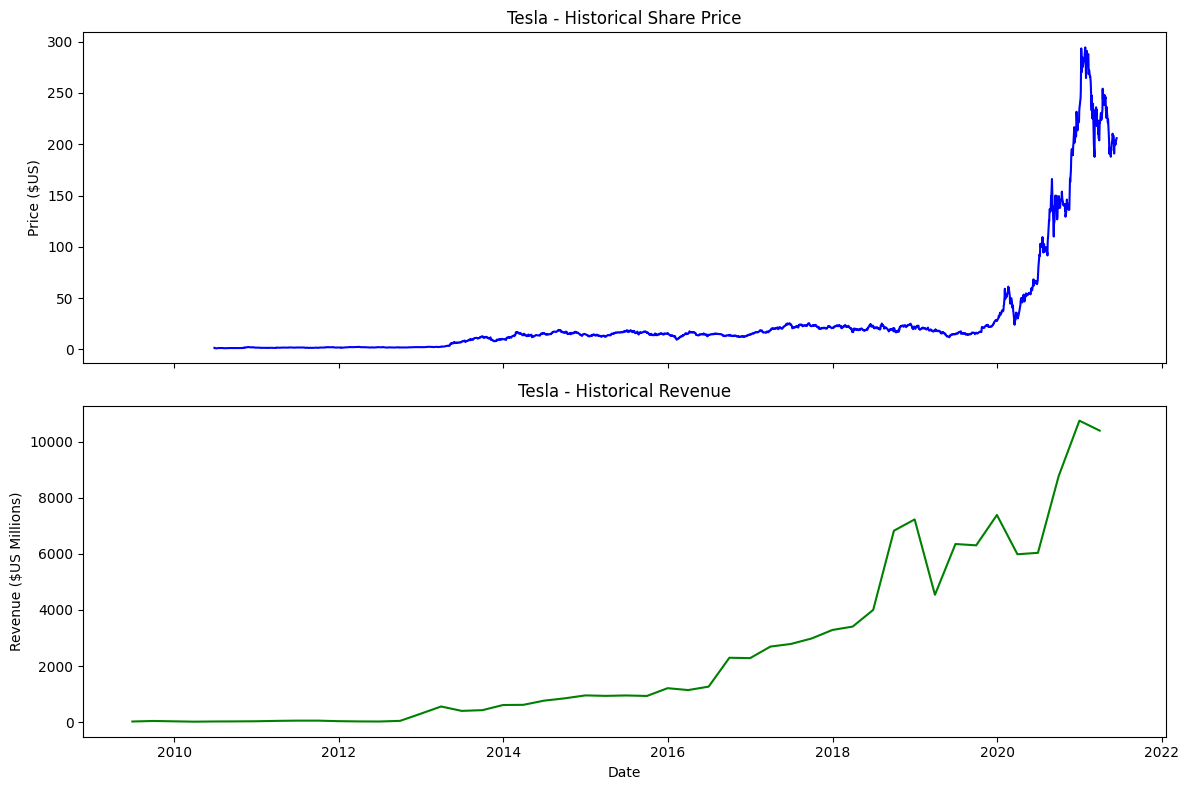

In [15]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

## Principais observações com Relação a TESLA:

A receita da **Tesla** cresceu de forma consistente, com aumento anual expressivo a partir de 2015. Entre 2010 a 2015, o crescimento foi linear, porém a partir de 2016, a curva se torna exponencial.

- **2016 → 2017:** +50%
- **2017 → 2018:** +55%
- **2018 → 2019:** +60%
- **2019 → 2020:** +44%
- **2020 → 2021:** +61,5% (maior salto absoluto: +4.000 milhões)

### Estabilização em 2022
Crescimento de apenas 300 milhões, sugerindo uma possível saturação ou impacto de fatores macroeconômicos, podendo citar a pandemia, crise dos semicondutores e expansão das operações da concorrente **BYD**.

### Relação com o preço das ações
Como esperado, o valor das ações acompanha o crescimento da receita, porém a curva de crescimento das ações só se torna exponencial por volta de 2020. A queda no valor das ações acompanha a desaceleração do crescimento da receita entre 2021 e 2022.

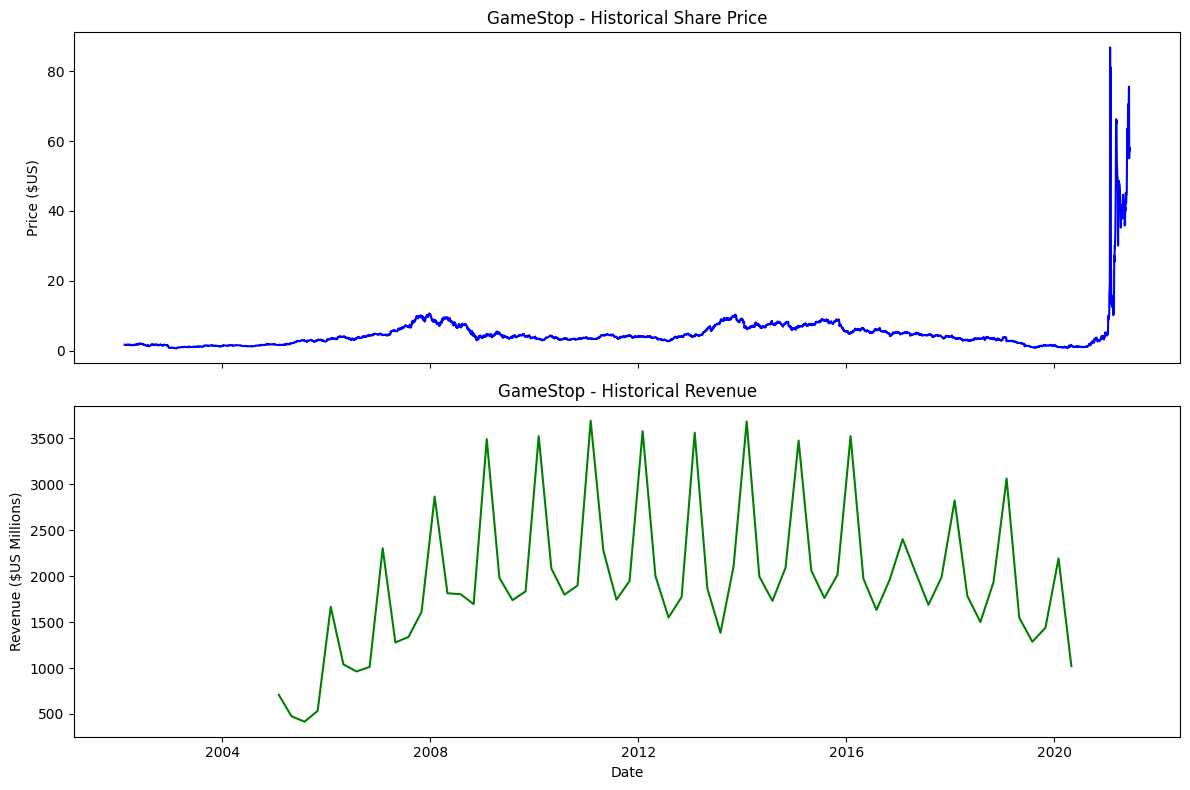

In [16]:
make_graph(gme_data, gme_revenue, 'GameStop')

## Principais observações com Relação a GAMESTOP:

### Volatilidade
O receita da GameStop apresenta uma oscilações entre picos e vales, com uma tendência de crescimento até aproximadamente o ano de 2015. Após 2015 a tendência é de queda porém com a mesma oscilação entre picos e vales.

### Contraste com o preço das ações
Em contraste os valores das ações apresentam estabilidade, linha quase horizontal, tendo rompido a resistência por volta de 2020 e apresentando um crescimento exponencial, porém ainda com muita volatilidade.